# Simulador de Alocação Dinâmica de Memória

Comparação entre First Fit, Best Fit e Worst Fit na alocação dinâmica.

## Descrição dos experimentos

São conduzidos três experimentos sobre os workloads de `inputs/`, em ordem crescente de carga. As métricas reportadas são: utilização final da memória, rejeições por fragmentação externa, rejeições por falta de memória, maior brecha livre final e número de fusões.

1. Workload simples (`inputs/workload_simples.json`) — 7 eventos sobre 1000 de memória. Validação de execução sem falhas.
2. Workload realista (`inputs/workload_complexo.json`) — 45 eventos sobre 2000 de memória, com FREEs intercalados ao longo de toda a sequência e vários pedidos grandes. Expõe a divergência de comportamento entre os algoritmos.
3. Workload de fragmentação (`inputs/workload_fragmentacao.json`) — 28 eventos sobre 1000 de memória, construído para produzir fragmentação externa: após liberar blocos não-adjacentes, pedidos que caberiam na soma das brechas são recusados porque nenhuma brecha individual os comporta.

Para cada experimento são produzidos: a tabela comparativa, o mapa de memória ao longo do tempo (endereço × evento) por algoritmo e gráficos de barras das métricas. No experimento 3 acrescenta-se a curva da maior brecha por evento.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))

from algorithms.instantiate_algorithms import instantiate_algorithms
from shared.parser import parse_input
from shared.plots import plot_largest_gap_evolution, plot_memory_timeline, plot_metric_bars, timeline
from shared.report import snapshot_summary, to_markdown
from shared.runner import run_simulation

In [13]:
ALGOS = instantiate_algorithms()


def summarize(path):
    results = run_simulation(parse_input(path))
    return [(r.algorithm, snapshot_summary(r.memory, r.stats)) for r in results]


def show_timelines(path):
    workload = parse_input(path)
    fig, axes = plt.subplots(len(ALGOS), 1, figsize=(11, 3.2 * len(ALGOS)), squeeze=False)
    for ax, (name, choose) in zip(axes[:, 0], ALGOS):
        plot_memory_timeline(timeline(workload, choose), workload.total_memory, ax=ax, title=name)
    fig.tight_layout()
    plt.show()


METRICAS = (
    ("final_utilization_pct", "Utilização final %"),
    ("external_fragmentation_failures", "Rejeições por fragmentação"),
    ("final_largest_gap", "Maior brecha final"),
)


def show_bars(reports):
    fig, axes = plt.subplots(1, len(METRICAS), figsize=(13, 3.2))
    for ax, (metric, label) in zip(axes, METRICAS):
        plot_metric_bars(reports, metric, ax=ax, label=label)
    fig.tight_layout()
    plt.show()

## Experimento 1 — Workload simples (validação)

Sequência curta (`inputs/workload_simples.json`), sem disputa por espaço, para validar o comportamento básico dos três algoritmos.

In [14]:
reports = summarize("inputs/workload_simples.json")
display(Markdown(to_markdown(reports)))

| Algoritmo | Alocados | Rej. frag. | Rej. s/ mem | Fusões | Util. final % | Maior brecha |
| :-- | --: | --: | --: | --: | --: | --: |
| first-fit | 5 | 0 | 0 | 0 | 50.0 | 400 |
| best-fit | 5 | 0 | 0 | 0 | 50.0 | 400 |
| worst-fit | 5 | 0 | 0 | 1 | 50.0 | 350 |

**Vencedor por métrica**

| Métrica | Vencedor |
| :-- | :-- |
| `external_fragmentation_failures` | first-fit |
| `no_space_failures` | first-fit |
| `total_rejected` | first-fit |
| `final_utilization_pct` | first-fit |

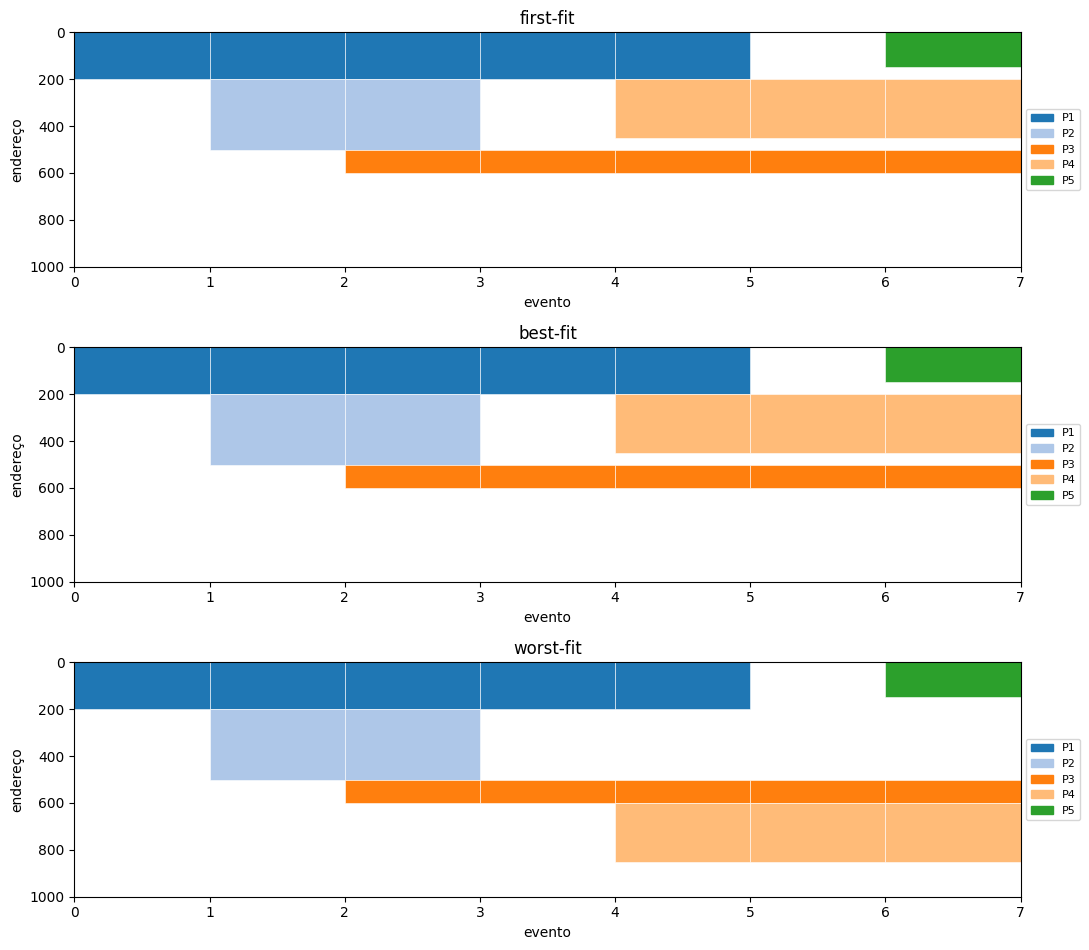

In [15]:
show_timelines("inputs/workload_simples.json")

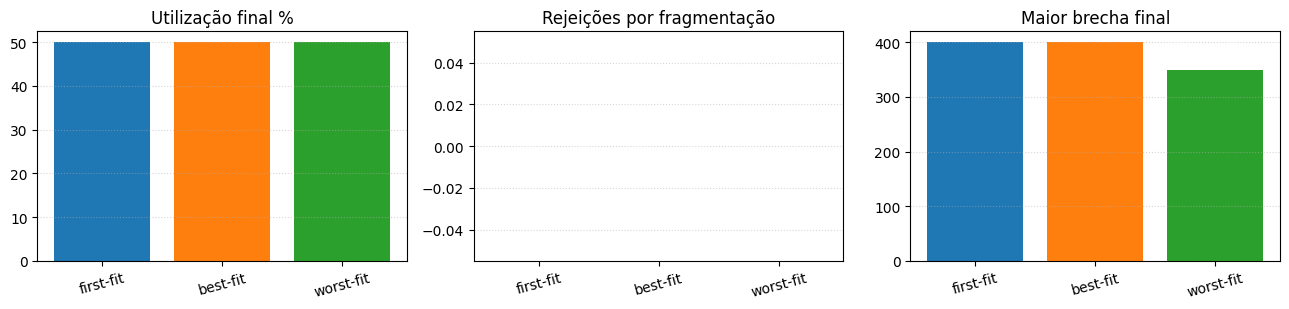

In [16]:
show_bars(reports)

### Constata-se que:

1. Os três algoritmos alocam os 5 processos sem nenhuma rejeição e terminam com a mesma utilização (50%).
2. A única diferença está no layout final: o Worst Fit, por sempre escolher a maior brecha, fragmenta a memória de forma distinta e termina com a maior brecha final um pouco menor 350 contra e uma fusão a mais.

## Experimento 2 — Workload realista (`workload_complexo.json`)

In [17]:
reports = summarize("inputs/workload_complexo.json")
display(Markdown(to_markdown(reports)))

| Algoritmo | Alocados | Rej. frag. | Rej. s/ mem | Fusões | Util. final % | Maior brecha |
| :-- | --: | --: | --: | --: | --: | --: |
| first-fit | 23 | 3 | 2 | 11 | 49.25 | 555 |
| best-fit | 24 | 2 | 2 | 13 | 94.75 | 85 |
| worst-fit | 23 | 3 | 2 | 14 | 49.25 | 480 |

**Vencedor por métrica**

| Métrica | Vencedor |
| :-- | :-- |
| `external_fragmentation_failures` | best-fit |
| `no_space_failures` | first-fit |
| `total_rejected` | best-fit |
| `final_utilization_pct` | best-fit |

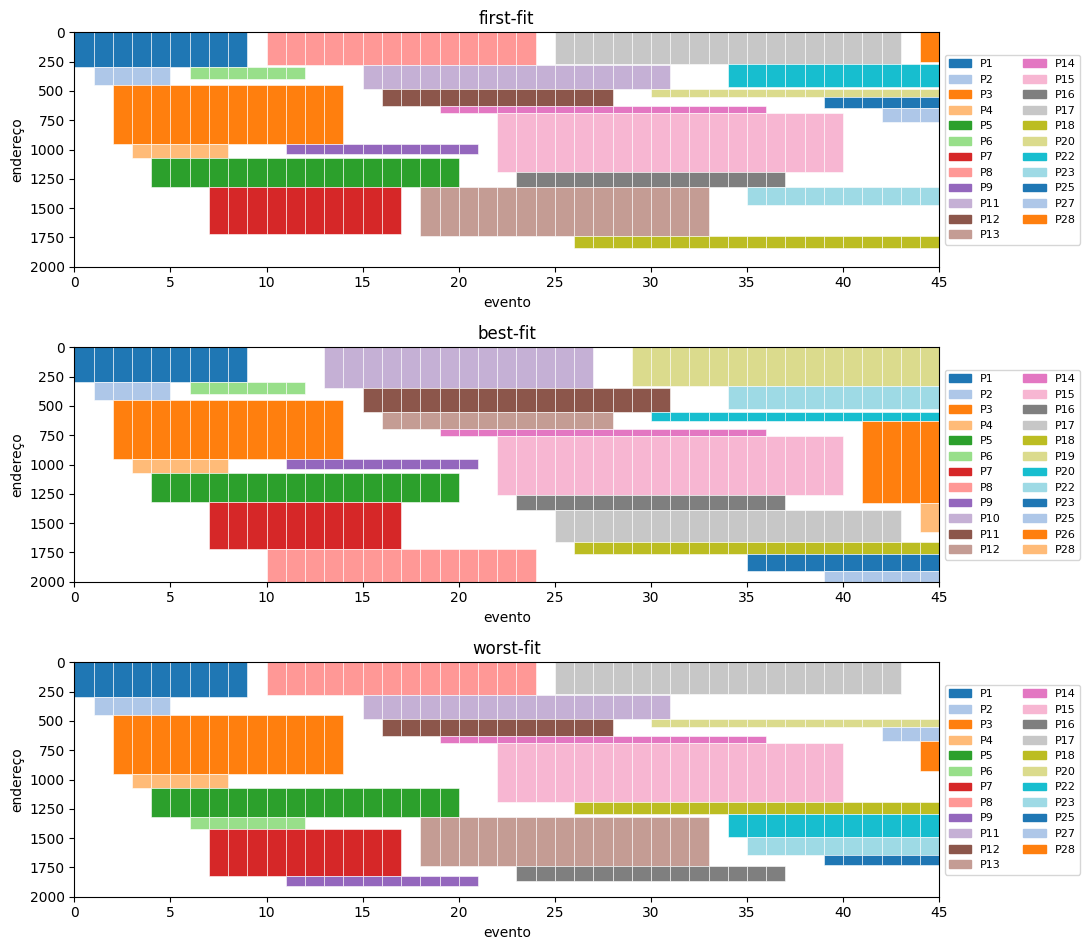

In [18]:
show_timelines("inputs/workload_complexo.json")

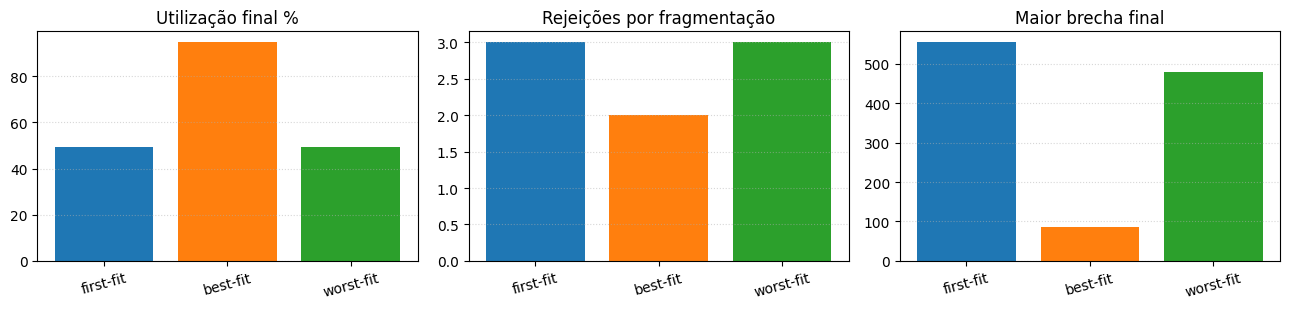

In [19]:
show_bars(reports)

### Constata-se que:

1. Best Fit apresenta com 94,75% de utilização alocando 24 processos, contra apenas 49,25% (23 processos) de First Fit e Worst Fit.
2. O Best Fit apresenta 4 rejeições no total, e termina com a menor brecha (85).
3. First Fit e Worst Fit ficam empatados em throughput (49,25%, 23 processos) e sofrem 3 rejeições por fragmentação externa cada.
4. A diferença entre First e Worst Fit aparece na maior brecha 555 vs. 480.

## Experimento 3 — Workload de fragmentação

In [20]:
reports = summarize("inputs/workload_fragmentacao.json")
display(Markdown(to_markdown(reports)))

| Algoritmo | Alocados | Rej. frag. | Rej. s/ mem | Fusões | Util. final % | Maior brecha |
| :-- | --: | --: | --: | --: | --: | --: |
| first-fit | 12 | 2 | 3 | 5 | 52.0 | 260 |
| best-fit | 12 | 2 | 3 | 5 | 52.0 | 260 |
| worst-fit | 12 | 3 | 2 | 6 | 67.0 | 250 |

**Vencedor por métrica**

| Métrica | Vencedor |
| :-- | :-- |
| `external_fragmentation_failures` | first-fit |
| `no_space_failures` | worst-fit |
| `total_rejected` | first-fit |
| `final_utilization_pct` | worst-fit |

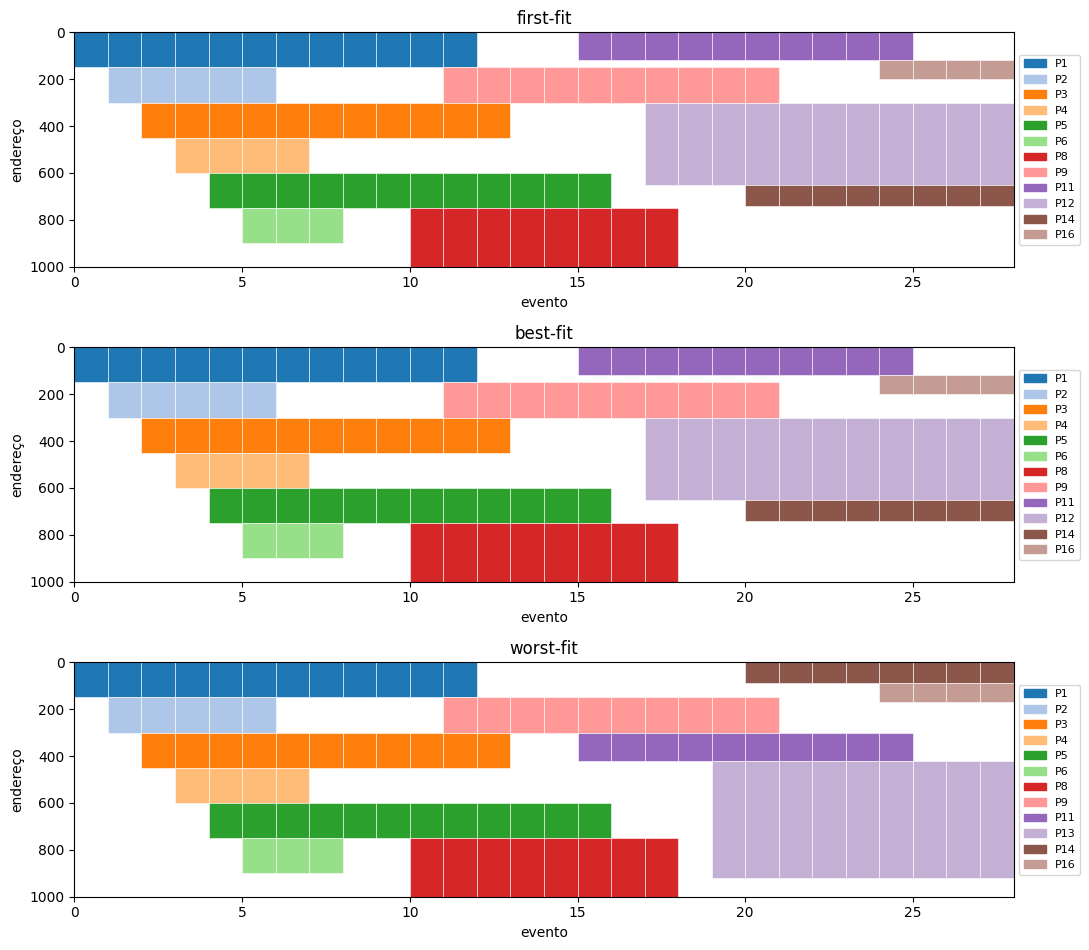

In [21]:
show_timelines("inputs/workload_fragmentacao.json")

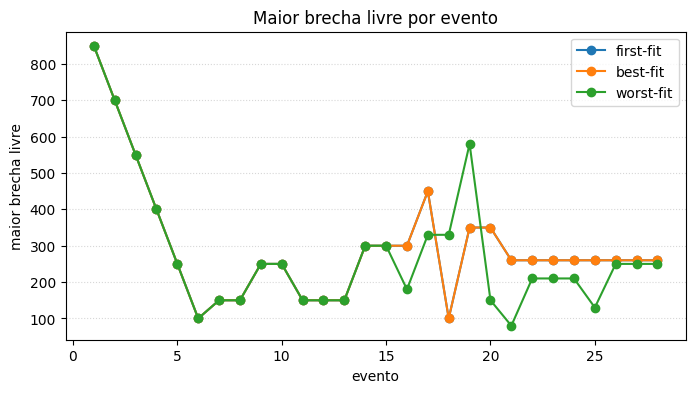

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_largest_gap_evolution(parse_input("inputs/workload_fragmentacao.json"), ALGOS, ax=ax)
ax.set_title("Maior brecha livre por evento")
plt.show()

### Constata-se que:

1. O pedido P7 = 300 é rejeitado por fragmentação externa nos três algoritmos
2. P13 = 500 e P17 = 1200 são rejeitados por falta de memória real.
3. Worst Fit termina com 67% que First/Best Fit (52%), mas com uma rejeição a mais por fragmentação (3 vs. 2).

## Conclusão

Os experimentos confirmam o comportamento distinto dos três algoritmos.

1. Best Fit maximiza a utilização e minimiza a fragmentação externa — no primeiro experimento chegou a 94,75% de utilização, contra 49,25% dos outros.
2. Worst Fit é o algortimo que mais fragmenta memória: no experimento de fragmentação, terminou com mais rejeições por fragmentação.